# Retail Markdown Pricing & Margin Impact: walkthrough

This notebook walks through the analysis step by step, using the tables built by `src/01_build_tables.py`.
Every number here matches the report in `report/` and `outputs/results.json`.

**Question:** when a beauty retailer marks a product down, how many extra units does it sell, and does that volume pay for the discount?

**Before running:** download the dataset into `data/` (see `data/README.md`) and run `python src/01_build_tables.py` from the repository root.

In [1]:
import os, json
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")                                   # work from the repository root

import duckdb, numpy as np, pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import Image, display
pd.set_option("display.precision", 3)

con = duckdb.connect("markdown.duckdb", read_only=True)
q = lambda sql: con.execute(sql).df()
q("SELECT 'products' AS tbl, COUNT(*) AS n FROM products UNION ALL SELECT 'events', COUNT(*) FROM events")

,tbl,n
0,products,43400
1,events,173600


## 1. Data quality

Two things came up in the audit: 350 exact duplicate rows (removed in SQL), and an `Optimal Discount` column that is almost exactly the average of each product's four markdowns. That column is derived from the inputs, so it can't be used as a target.

In [2]:
q("""
SELECT ROUND(CORR(Optimal_Discount, (Markdown_1 + Markdown_2 + Markdown_3 + Markdown_4) / 4), 3) AS corr_optimal_vs_avg_markdown,
       ROUND(100 * AVG((Markdown_1 + Markdown_2 + Markdown_3 + Markdown_4) / 4), 1)            AS actual_avg_depth_pct
FROM products
""")

,corr_optimal_vs_avg_markdown,actual_avg_depth_pct
0,0.997,30.0


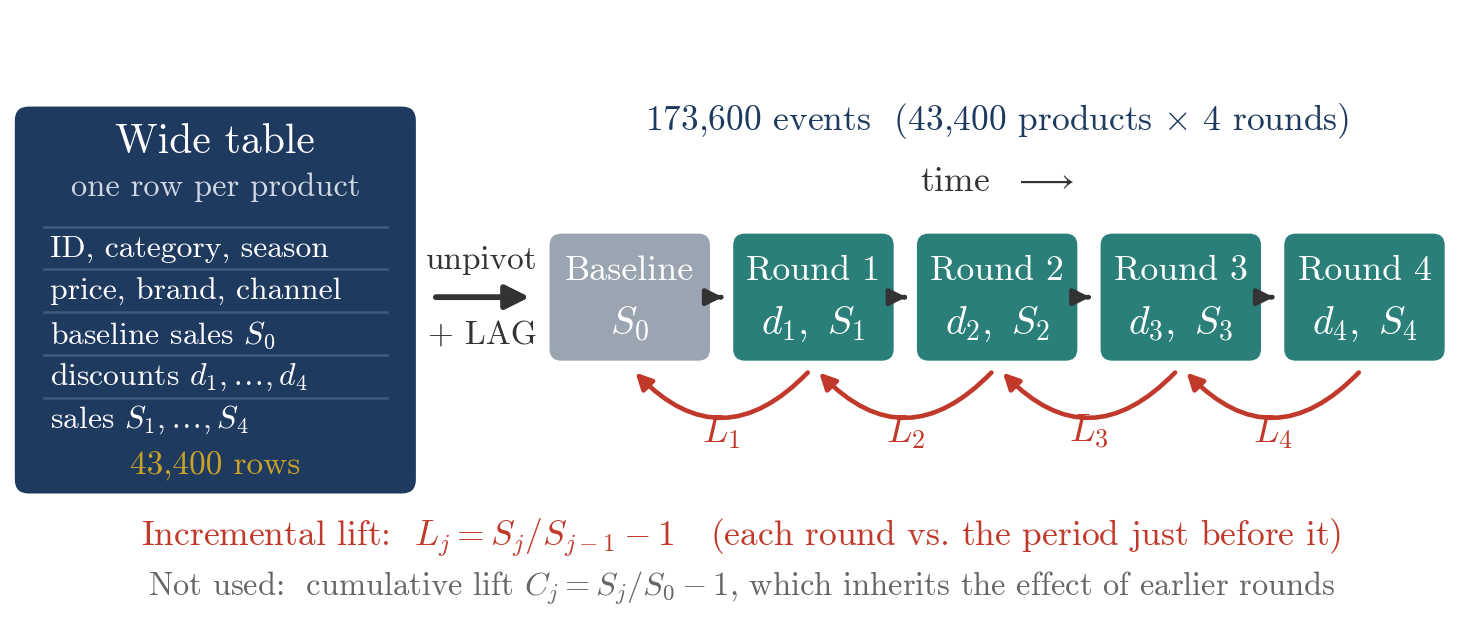

In [3]:
display(Image("outputs/figures/fig00a_reshape.png", width=800))

## 2. The attribution trap: cumulative vs incremental lift

Sales carry forward from one markdown round to the next. Comparing every round with the original baseline therefore credits later rounds with earlier growth.

In [4]:
q("""
SELECT stage AS round,
       ROUND(100 * AVG(markdown), 1)   AS mean_depth,
       ROUND(100 * AVG(step_lift), 1)  AS incremental_lift,
       ROUND(100 * AVG(cum_lift), 1)   AS cumulative_lift
FROM events GROUP BY stage ORDER BY stage
""")

,round,mean_depth,incremental_lift,cumulative_lift
0,1,25.1,15.0,15.0
1,2,35.0,20.9,40.0
2,3,20.0,11.9,58.3
3,4,40.0,23.9,100.8


Round 3 (20% off) looks better than round 2 (35% off) on the cumulative view: 58% vs 40%. Measured incrementally, it added 12% vs 21%. Everything below uses incremental lift.

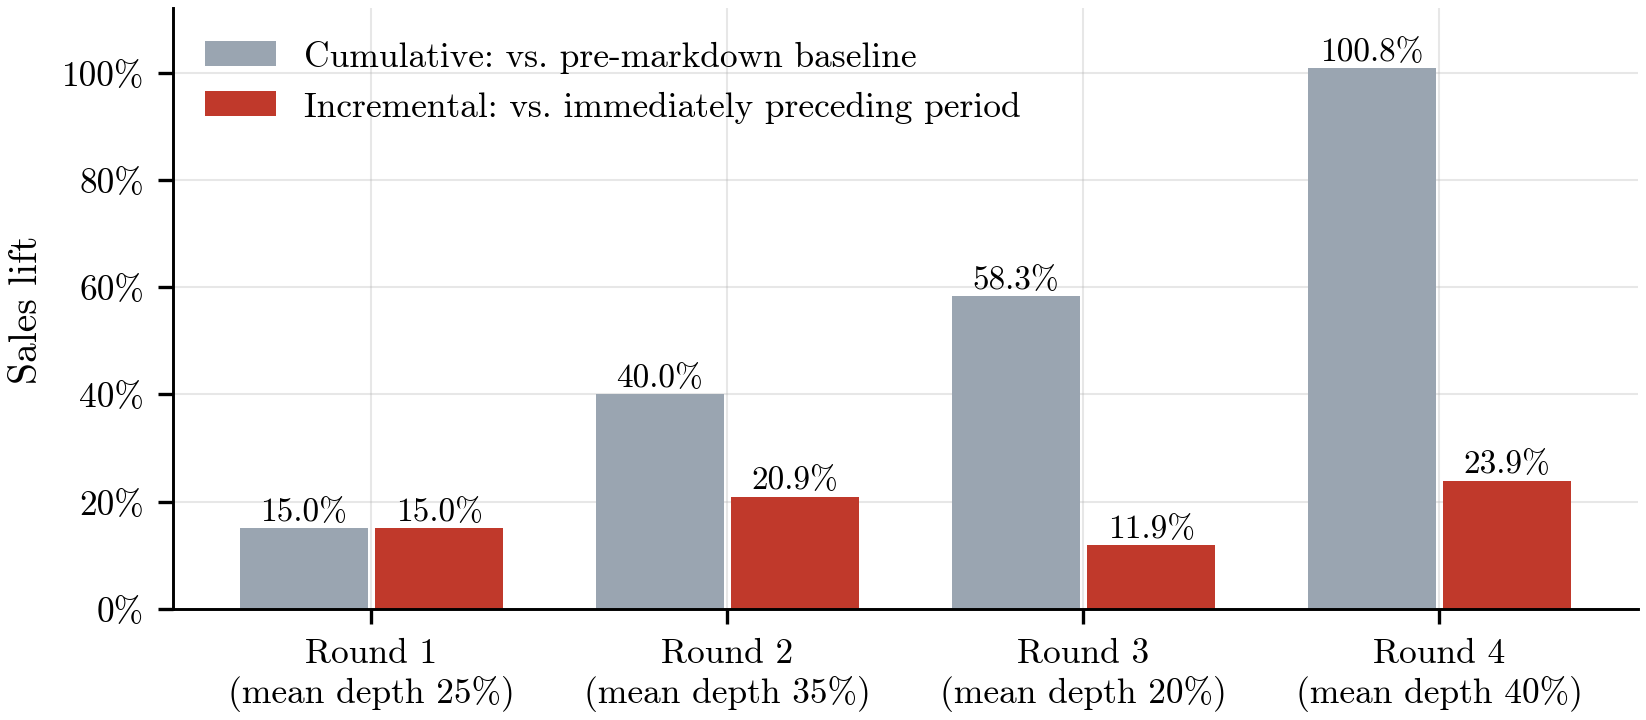

In [5]:
display(Image("outputs/figures/fig02_attribution.png", width=750))

## 3. What drives the response to a discount?

Lift grows roughly in proportion to depth, so the models have no intercept and estimate a slope: points of lift per point of discount. Standard errors are clustered by product because each product contributes four events.

In [6]:
e = q("SELECT * FROM events ORDER BY Product_ID, stage")
e["segment"] = e.Season + "-" + e.Category
ctrl = " + markdown:C(Promotion_Type) + markdown:C(Brand) + markdown:price_gap_vs_competitor + C(stage)"
cl = dict(cov_type="cluster", cov_kwds={"groups": e.Product_ID})
r2 = lambda m: 1 - ((e.step_lift - m.fittedvalues) ** 2).sum() / ((e.step_lift - e.step_lift.mean()) ** 2).sum()

m1 = smf.ols("step_lift ~ markdown", data=e).fit()
m2 = smf.ols("step_lift ~ markdown + markdown:Seasonality_Factor" + ctrl, data=e).fit(**cl)
m3 = smf.ols("step_lift ~ 0 + markdown:C(segment)" + ctrl, data=e).fit(**cl)
m4 = smf.ols("step_lift ~ 0 + markdown:C(segment) + markdown:Seasonality_Factor" + ctrl, data=e).fit(**cl)

pd.DataFrame({
    "model": ["M1: depth", "M2: depth x seasonality factor", "M3: depth x season x category", "M4: M3 + seasonality factor"],
    "R2": [r2(m) for m in (m1, m2, m3, m4)],
    "seasonality_coef": [None, m2.params["markdown:Seasonality_Factor"], None, m4.params["markdown:Seasonality_Factor"]],
    "seasonality_p": [None, m2.pvalues["markdown:Seasonality_Factor"], None, m4.pvalues["markdown:Seasonality_Factor"]],
}).round(4)

,model,R2,seasonality_coef,seasonality_p
0,M1: depth,0.212,NaN,NaN
1,M2: depth x seasonality factor,0.486,4.971e-01,0.000
2,M3: depth x season x category,0.791,NaN,NaN
3,M4: M3 + seasonality factor,0.791,2.000e-04,0.947


The seasonality factor looks important on its own (M2), but once season and category are in the model it has no effect at all (M4, p ≈ 0.95). It was a proxy. The real driver is whether the category is in season:

In [7]:
slopes = m3.params.filter(like="segment").rename(lambda s: s.split("[")[1].rstrip("]"))
slopes = slopes.sort_values(ascending=False).to_frame("slope")
slopes["season_fit"] = np.where(slopes.slope > 0.5, "in season", "off season")
print("Slope ratio, in vs off season:", round(slopes.query("season_fit == 'in season'").slope.mean() /
                                           slopes.query("season_fit == 'off season'").slope.mean(), 1))
slopes

Slope ratio, in vs off season: 5.6


,slope,season_fit
Winter-Makeup,0.856,in season
Winter-Bodycare,0.854,in season
Rainy-Bodycare,0.854,in season
Winter-Skincare,0.853,in season
Summer-Skincare,0.853,in season
Summer-Bodycare,0.852,in season
Spring-Makeup,0.851,in season
Summer-Makeup,0.850,in season
Rainy-Skincare,0.153,off season
Spring-Bodycare,0.152,off season


In [8]:
e["elasticity"] = -e.step_lift / e.markdown
e["in_season"] = e.segment.isin(slopes.query("season_fit == 'in season'").index)
pd.Series({"overall": e.elasticity.median(),
           "in season": e.loc[e.in_season, "elasticity"].median(),
           "off season": e.loc[~e.in_season, "elasticity"].median()}, name="median elasticity").round(2)

overall      -0.65
in season    -0.85
off season   -0.15
Name: median elasticity, dtype: float64

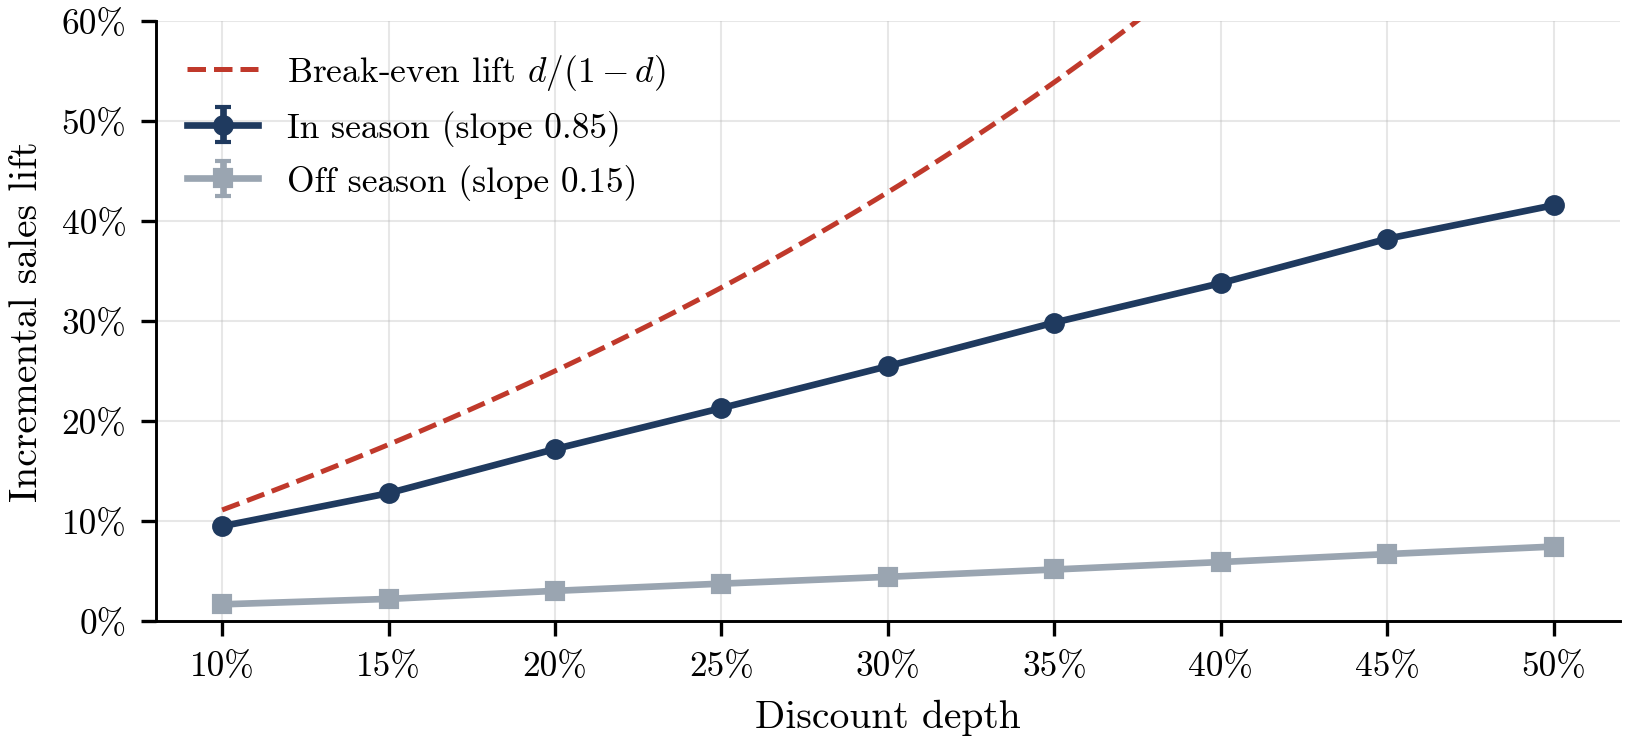

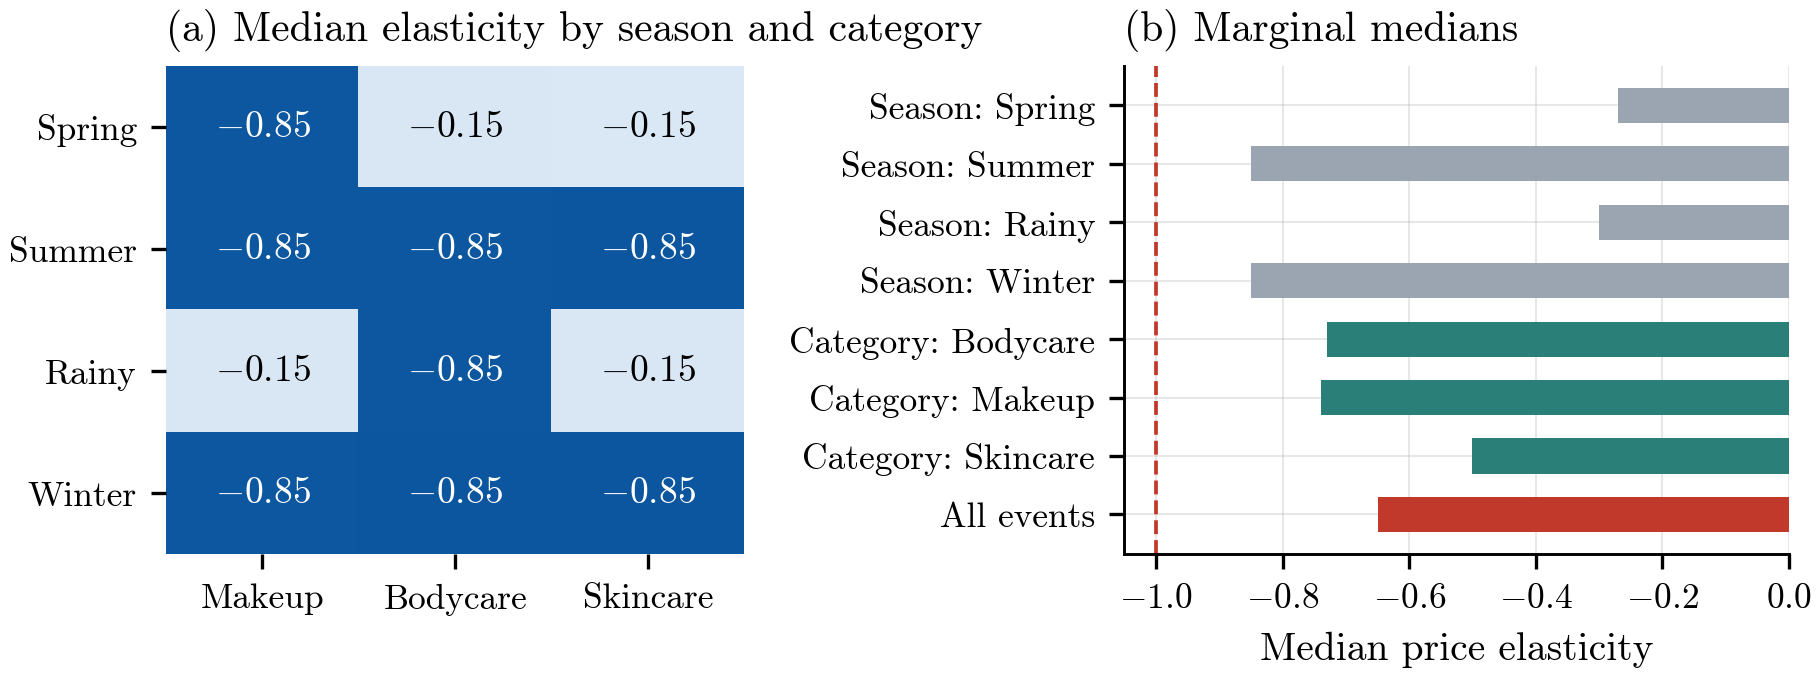

In [9]:
display(Image("outputs/figures/fig03_lift_by_regime.png", width=750))
display(Image("outputs/figures/fig04_elasticity.png", width=750))

## 4. Do discount tiers really differ? ANOVA, Kruskal–Wallis, Tukey HSD

The four rounds of one product are not independent, so one round is drawn at random per product before testing.

In [10]:
p = q("SELECT Product_ID FROM products ORDER BY Product_ID")
rng = np.random.default_rng(42)
pick = pd.DataFrame({"Product_ID": p.Product_ID.values, "stage": rng.integers(1, 5, len(p))})
one = e.merge(pick, on=["Product_ID", "stage"])
one["rev_change"] = (1 - one.markdown) * (1 + one.step_lift) - 1

groups = [g.step_lift.values for _, g in one.groupby("discount_band")]
F, pF = stats.f_oneway(*groups); H, pH = stats.kruskal(*groups)
print(f"ANOVA F = {F:,.1f} (p = {pF:.1e})   Kruskal-Wallis H = {H:,.1f} (p = {pH:.1e})")
(one.groupby("discount_band")
    .agg(n=("step_lift", "size"), unit_lift_pct=("step_lift", "mean"), revenue_change_pct=("rev_change", "mean"))
    .assign(unit_lift_pct=lambda d: d.unit_lift_pct * 100, revenue_change_pct=lambda d: d.revenue_change_pct * 100).round(1))

ANOVA F = 3,434.1 (p = 0.0e+00)   Kruskal-Wallis H = 7,678.2 (p = 0.0e+00)


,n,unit_lift_pct,revenue_change_pct
discount_band,,,
10-20%,8653,8.9,-7.2
20-30%,12402,14.7,-13.5
30-40%,12749,20.6,-21.1
40-50%,9596,26.6,-30.0


In [11]:
print(pairwise_tukeyhsd(one.step_lift * 100, one.discount_band))

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
10-20% 20-30%   5.8531   0.0  5.3984  6.3078   True
10-20% 30-40%  11.7108   0.0 11.2587  12.163   True
10-20% 40-50%  17.7061   0.0 17.2249 18.1873   True
20-30% 30-40%   5.8577   0.0  5.4483  6.2671   True
20-30% 40-50%   11.853   0.0 11.4117 12.2943   True
30-40% 40-50%   5.9953   0.0  5.5566   6.434   True
---------------------------------------------------


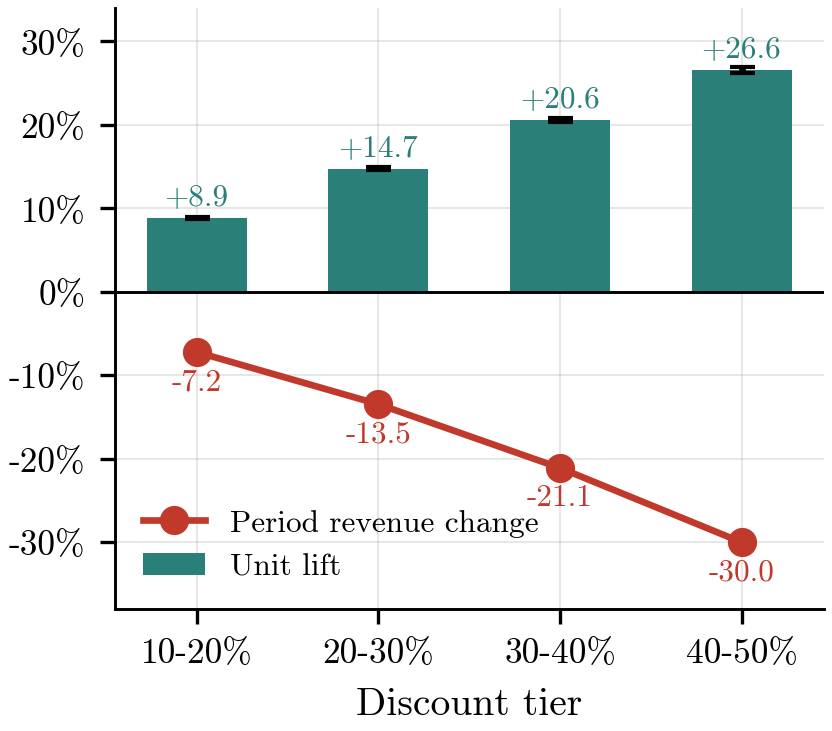

In [12]:
display(Image("outputs/figures/fig06_tiers.png", width=420))

## 5. Did the markdowns make money? Counterfactual revenue and margin

Actual revenue and contribution margin over the four rounds vs a world with no markdowns (full price, baseline volume). Product cost isn't in the data, so COGS is assumed at 40% of price and tested at 30% and 50%.

In [13]:
cf = []
for cogs in (0.3, 0.4, 0.5):
    cf.append(q(f"""
    SELECT {cogs} AS cogs,
           ROUND(100 * (SUM(Original_Price * (1 - markdown) * sales) / SUM(Original_Price * prev_sales_base) - 1), 1)  AS revenue_pct,
           ROUND(100 * (SUM(Original_Price * (1 - markdown - {cogs}) * sales)
                        / SUM(Original_Price * (1 - {cogs}) * prev_sales_base) - 1), 1)                                 AS margin_pct
    FROM (SELECT e.*, p.Historical_Sales AS prev_sales_base FROM events e JOIN products p USING (Product_ID))
    """))
pd.concat(cf, ignore_index=True)

,cogs,revenue_pct,margin_pct
0,0.3,10.7,-10.9
1,0.4,10.7,-22.9
2,0.5,10.7,-39.7


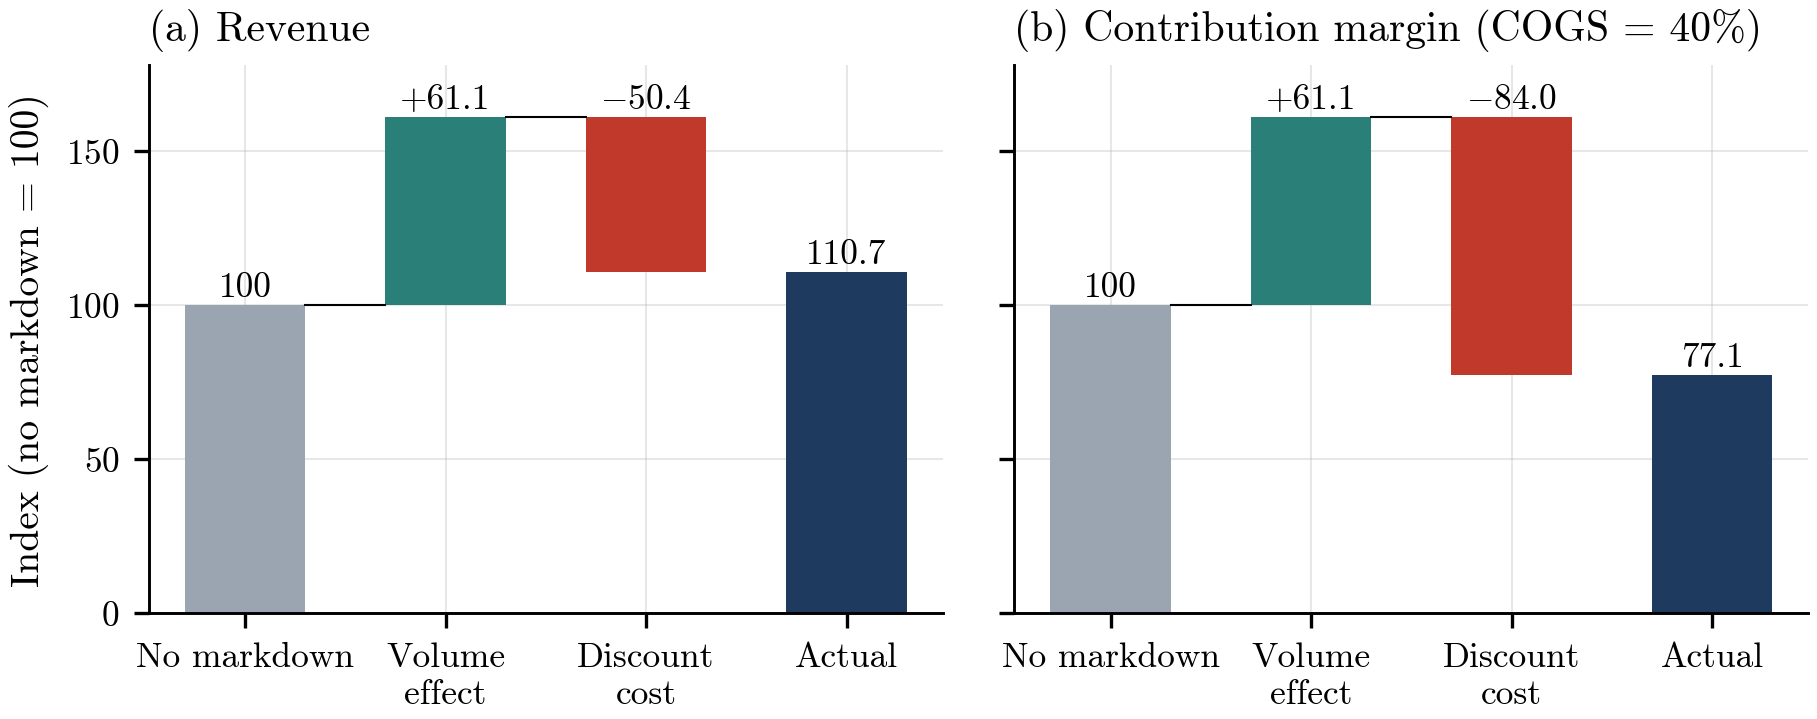

In [14]:
display(Image("outputs/figures/fig09_waterfall.png", width=750))

## 6. What policy would have done better?

Holding one depth for all four rounds, using each segment's estimated slope:

In [15]:
R = json.load(open("outputs/results.json"))
pd.DataFrame(R["policy"]["by_segment"]).sort_values("slope", ascending=False).reset_index(drop=True)

,segment,slope,margin_best_depth,margin_at_best_pct,revenue_best_depth,revenue_at_best_pct,margin_at_revenue_best_pct
0,Winter-Makeup,0.856,0.1,2.8,0.45,32.6,-39.7
1,Rainy-Bodycare,0.854,0.1,2.7,0.45,32.3,-39.8
2,Winter-Bodycare,0.854,0.1,2.7,0.45,32.4,-39.8
3,Winter-Skincare,0.853,0.1,2.7,0.45,32.3,-39.9
4,Summer-Skincare,0.853,0.1,2.7,0.45,32.2,-39.9
5,Summer-Bodycare,0.852,0.1,2.7,0.45,32.1,-40.0
6,Spring-Makeup,0.851,0.1,2.6,0.45,32.0,-40.0
7,Summer-Makeup,0.850,0.1,2.6,0.45,31.9,-40.1
8,Rainy-Skincare,0.153,0.1,-13.4,0.10,-6.5,-13.4
9,Spring-Bodycare,0.152,0.1,-13.5,0.10,-6.5,-13.5


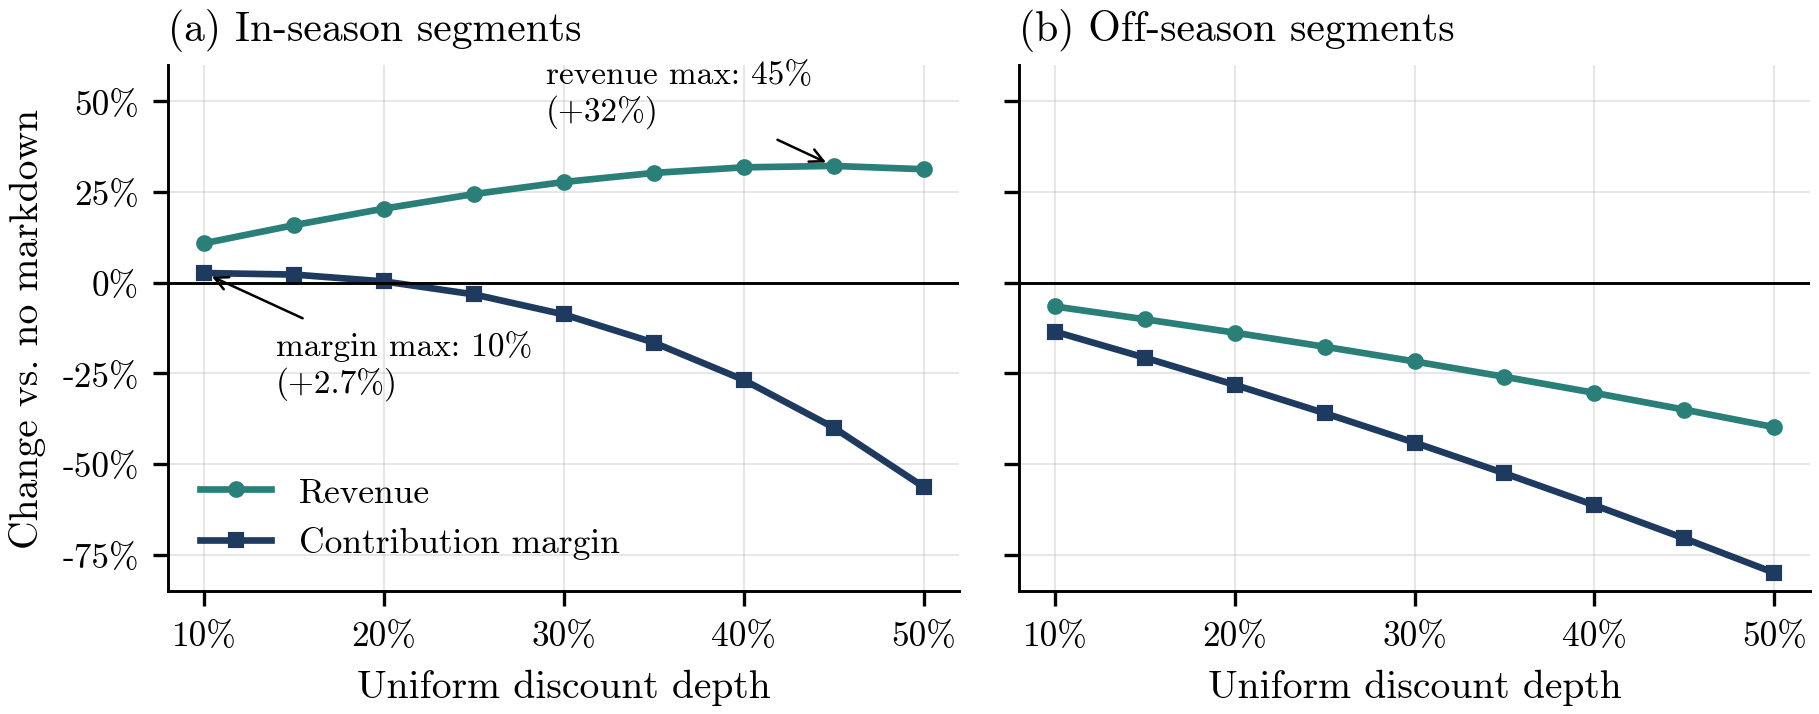

In [16]:
display(Image("outputs/figures/fig10_policy.png", width=750))

## Takeaways

1. **Measure incremental lift.** The cumulative view mis-ranked the markdown rounds.
2. **Demand is price-inelastic** (median elasticity −0.65). Almost no markdown recovered its own discount.
3. **Season fit drives the response**, not the seasonality score, channel or competitor price: in-season products respond ~5.6× more.
4. **Revenue rose 10.7% but contribution margin fell 22.9%** (COGS 40%), and the margin loss holds at 30% and 50% COGS.
5. **Policy:** no off-season markdowns; cap in-season markdowns near 10%. Setting depth by revenue would push it to 45% and cost ~40% of margin.

Limitations: synthetic data, no undiscounted control group, assumed COGS, inventory not modelled. See the report for details.